In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def nail_tip_from_mask(img_path, tip_ratio=0.25, show=True):

    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # LAB
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    _, A, _ = cv2.split(lab)

    _, thresh = cv2.threshold(A, 0, 255, cv2.THRESH_TRIANGLE)

    mask = thresh
    roi = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)

    # ----------------------------
    # 1. contour bul
    # ----------------------------
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        raise ValueError("Contour bulunamadı!")

    # en büyük contour (parmak)
    c = max(contours, key=cv2.contourArea)

    # ----------------------------
    # 2. bounding box
    # ----------------------------
    x, y, w, h = cv2.boundingRect(c)

    # ----------------------------
    # 3. uç kısmı al (alt taraf)
    # ----------------------------
    # üst (proximal) kısmı al
    tip_h = int(h * tip_ratio)

    roi_tip = roi[y : y + tip_h, x : x + w]

    # ----------------------------
    # görselleştirme
    # ----------------------------
    if show:
        plt.figure(figsize=(15,4))

        plt.subplot(1,3,1)
        plt.title("ROI (Parmak)")
        plt.imshow(roi)
        plt.axis("off")

        plt.subplot(1,3,2)
        plt.title("Mask")
        plt.imshow(mask, cmap="gray")
        plt.axis("off")

        plt.subplot(1,3,3)
        plt.title("Tip (Uç Bölge)")
        plt.imshow(roi_tip)
        plt.axis("off")

        plt.show()

    return roi, mask, roi_tip

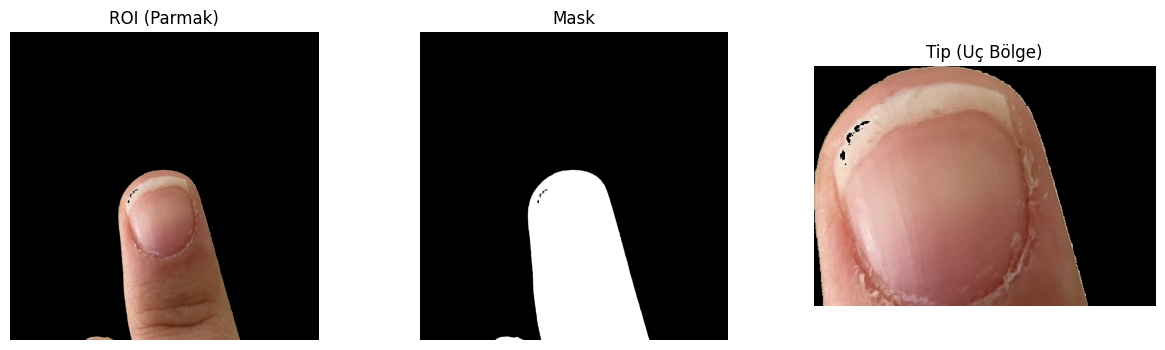

In [ ]:
img_path = "/content/drive/MyDrive/anemia_detection/test_dataset/nail1_1.JPG"  # kendi dosya yolunu yaz

roi, mask, roi_tip = nail_tip_from_mask(
    img_path,
    tip_ratio=0.5
)

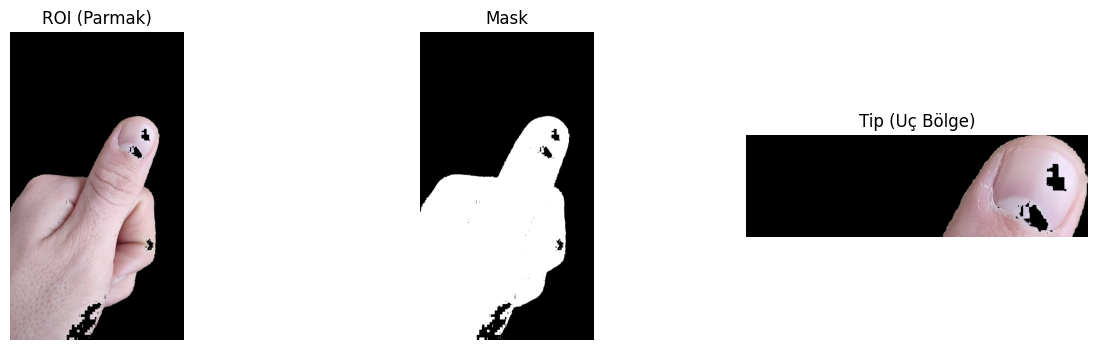

In [ ]:
img_path = "/content/drive/MyDrive/anemia_detection/test_dataset/nail2_1.jpeg"  # kendi dosya yolunu yaz

roi, mask, roi_tip = nail_tip_from_mask(
    img_path,
    tip_ratio=0.2
)

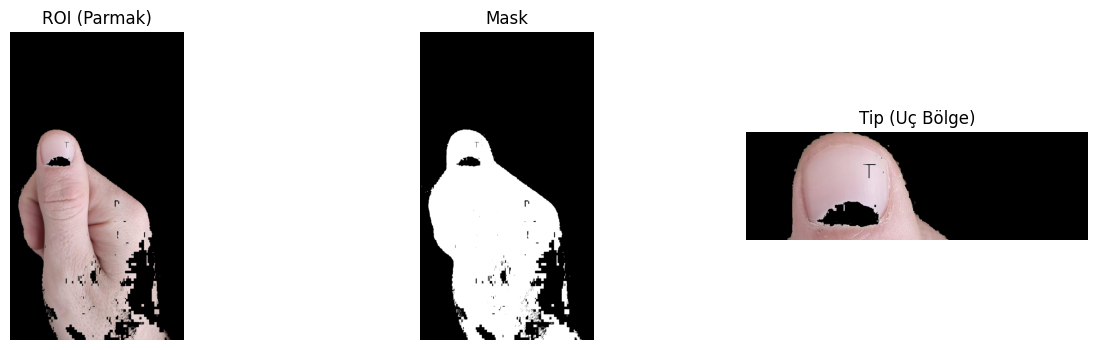

In [ ]:
img_path = "/content/drive/MyDrive/anemia_detection/test_dataset/nail2_2.jpeg"  # kendi dosya yolunu yaz

roi, mask, roi_tip = nail_tip_from_mask(
    img_path,
    tip_ratio=0.2
)

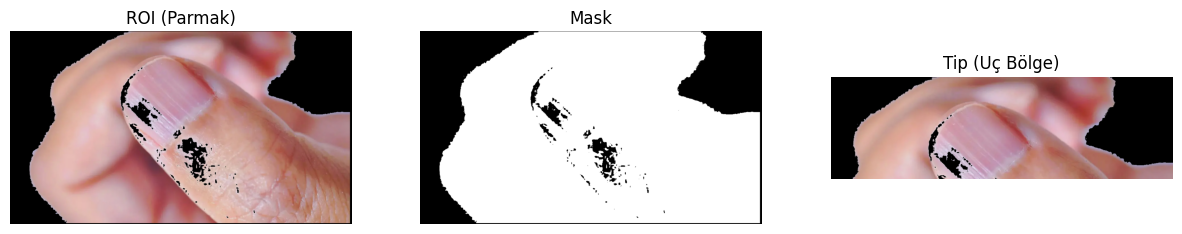

In [ ]:
img_path = "/content/drive/MyDrive/anemia_detection/test_dataset/nail3_1.png"  # kendi dosya yolunu yaz

roi, mask, roi_tip = nail_tip_from_mask(
    img_path,
    tip_ratio=0.5
)

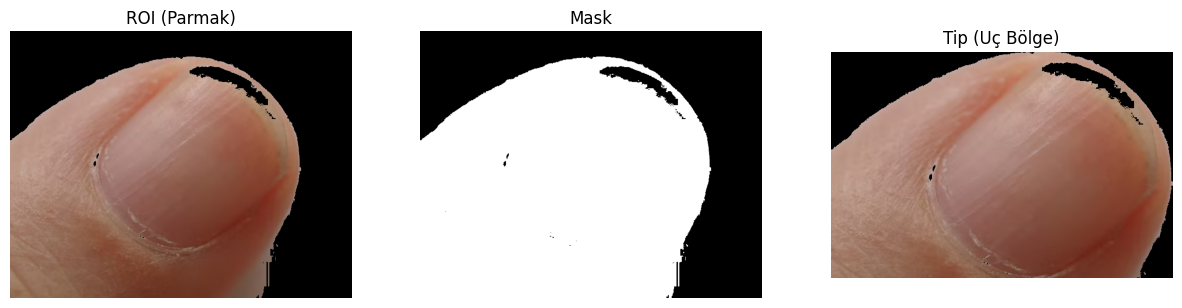

In [ ]:
img_path = "/content/drive/MyDrive/anemia_detection/test_dataset/nail3_2.png"  # kendi dosya yolunu yaz

roi, mask, roi_tip = nail_tip_from_mask(
    img_path,
    tip_ratio=0.8
)

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def nail_roi(img_path, show=True):
    """
    Konjonktiva bölgesini LAB renk uzayında A kanalı üzerinden çıkarır.

    Returns:
        img_rgb : Orijinal RGB görüntü
        mask    : Oluşturulan binary maske
        roi     : Maskelenmiş konjonktiva bölgesi
    """

    # Görüntüyü oku
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Görüntü okunamadı: {img_path}")

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # LAB renk uzayına çevir
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    _, A, _ = cv2.split(lab)

    # Triangle threshold
    _, thresh = cv2.threshold(A, 0, 255, cv2.THRESH_TRIANGLE)

    # Maskeyi ters çevir (konjonktiva genelde açık ton)
    mask = thresh
    # ROI çıkar
    roi = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)

    # Görselleştirme (opsiyonel)
    if show:
        plt.figure(figsize=(12,4))

        plt.subplot(1,3,1)
        plt.title("Orijinal")
        plt.imshow(img_rgb)
        plt.axis("off")

        plt.subplot(1,3,2)
        plt.title("Mask")
        plt.imshow(mask, cmap='gray')
        plt.axis("off")

        plt.subplot(1,3,3)
        plt.title("ROI (Konjunktiva)")
        plt.imshow(roi)
        plt.axis("off")

        plt.show()

    return img_rgb, mask, roi

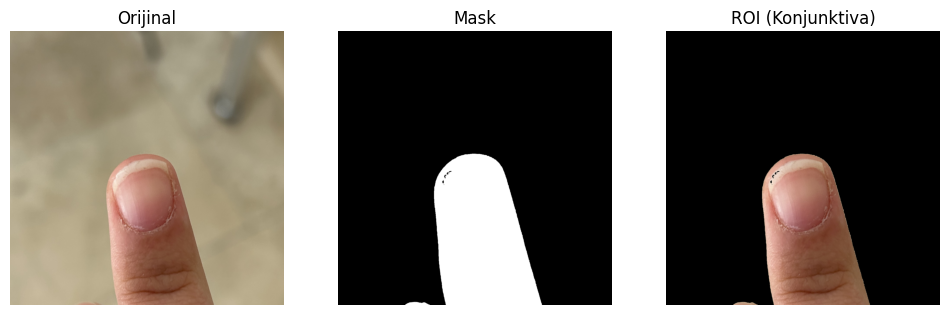

In [ ]:
img_path = "/content/drive/MyDrive/anemia_detection/test_dataset/nail1_1.JPG"  # kendi dosya yolunu yaz

img_rgb, mask, roi = nail_roi(img_path, show=True)

In [ ]:
import cv2
import numpy as np

def extract_nail_from_roi(roi, show=True):

    # 1. HSV çevir
    hsv = cv2.cvtColor(roi, cv2.COLOR_RGB2HSV)
    h, s, v = cv2.split(hsv)

    # 2. Tırnak için kriterler:
    # - düşük saturation (beyaz/pembe tırnak)
    # - yüksek brightness (V channel)

    low_s = cv2.inRange(s, 0, 60)
    high_v = cv2.inRange(v, 120, 255)

    mask = cv2.bitwise_and(low_s, high_v)

    # 3. Morphology cleanup
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)

    # 4. En büyük component seç (tırnak)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    nail_mask = np.zeros_like(mask)

    if len(contours) > 0:
        c = max(contours, key=cv2.contourArea)
        cv2.drawContours(nail_mask, [c], -1, 255, -1)

    # 5. ROI extraction
    nail_roi_img = cv2.bitwise_and(roi, roi, mask=nail_mask)

    return nail_mask, nail_roi_img

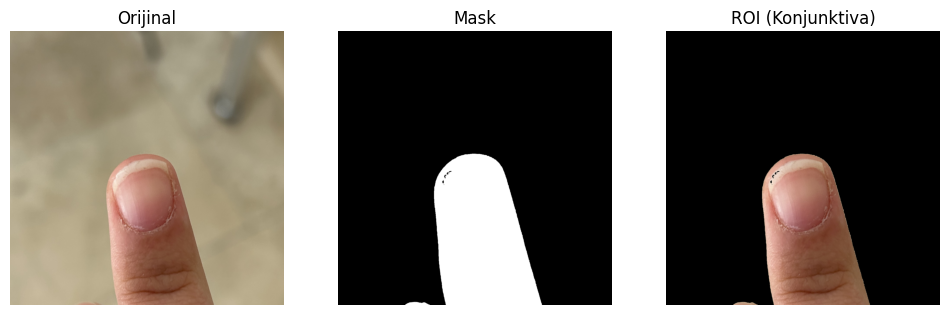

In [ ]:
img_rgb, mask, roi = nail_roi(img_path, show=True)

nail_mask, nail_roi_img = extract_nail_from_roi(roi, show=True)

In [ ]:

def extract_nail_roi(
    image_path,
    save_path=None,
    show_steps=True
):

    import cv2
    import numpy as np
    import matplotlib.pyplot as plt

    # ------------------------------------------------
    # 1. READ IMAGE
    # ------------------------------------------------
    img = cv2.imread(image_path)

    if img is None:
        raise ValueError("Image could not be read!")

    # ------------------------------------------------
    # 2. RESIZE TO 300x300
    # ------------------------------------------------
    img = cv2.resize(img, (300, 300))

    # ------------------------------------------------
    # 3. RGB -> GRAYSCALE
    # ------------------------------------------------
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # ------------------------------------------------
    # 4. MEDIAN FILTER (3x3)
    # ------------------------------------------------
    median = cv2.medianBlur(gray, 3)

    # ------------------------------------------------
    # 5. CLAHE
    # ------------------------------------------------
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    enhanced = clahe.apply(median)

    # ------------------------------------------------
    # 6. GLOBAL THRESHOLDING (0.5)
    # ------------------------------------------------
    threshold_value = int(0.5 * 255)

    _, thresh = cv2.threshold(
        enhanced,
        threshold_value,
        255,
        cv2.THRESH_BINARY
    )

    # ------------------------------------------------
    # 7. GABOR FILTERING
    # ------------------------------------------------
    ksize = 21
    sigma = 5
    theta = 0
    lambd = 10
    gamma = 0.5

    gabor_kernel = cv2.getGaborKernel(
        (ksize, ksize),
        sigma,
        theta,
        lambd,
        gamma,
        0,
        ktype=cv2.CV_32F
    )

    gabor = cv2.filter2D(
        thresh,
        cv2.CV_8UC3,
        gabor_kernel
    )

    # ------------------------------------------------
    # 8. MORPHOLOGICAL OPERATIONS
    # ------------------------------------------------
    kernel = np.ones((5, 5), np.uint8)

    morph = cv2.morphologyEx(
        gabor,
        cv2.MORPH_CLOSE,
        kernel
    )

    morph = cv2.morphologyEx(
        morph,
        cv2.MORPH_OPEN,
        kernel
    )

    # ------------------------------------------------
    # 9. REGION-BASED SEGMENTATION
    # ------------------------------------------------
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        morph,
        connectivity=8
    )

    largest_label = 1
    largest_area = 0

    for i in range(1, num_labels):

        area = stats[i, cv2.CC_STAT_AREA]

        if area > largest_area:
            largest_area = area
            largest_label = i

    # ------------------------------------------------
    # 10. CREATE MASK
    # ------------------------------------------------
    mask = np.zeros_like(gray)

    mask[labels == largest_label] = 255

    # ------------------------------------------------
    # 11. APPLY MASK
    # ------------------------------------------------
    roi = cv2.bitwise_and(
        img,
        img,
        mask=mask
    )

    # ------------------------------------------------
    # 12. SAVE ROI
    # ------------------------------------------------
    if save_path is not None:
        cv2.imwrite(save_path, roi)

    # ------------------------------------------------
    # 13. SHOW STEPS
    # ------------------------------------------------
    if show_steps:

        titles = [
            "Original",
            "Gray",
            "Median",
            "CLAHE",
            "Threshold",
            "Gabor",
            "Morphology",
            "Mask",
            "ROI"
        ]

        images = [
            cv2.cvtColor(img, cv2.COLOR_BGR2RGB),
            gray,
            median,
            enhanced,
            thresh,
            gabor,
            morph,
            mask,
            cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)
        ]

        plt.figure(figsize=(18,10))

        for i in range(len(images)):

            plt.subplot(3,3,i+1)

            if len(images[i].shape) == 2:
                plt.imshow(images[i], cmap='gray')
            else:
                plt.imshow(images[i])

            plt.title(titles[i])
            plt.axis("off")

        plt.tight_layout()
        plt.show()

    return roi


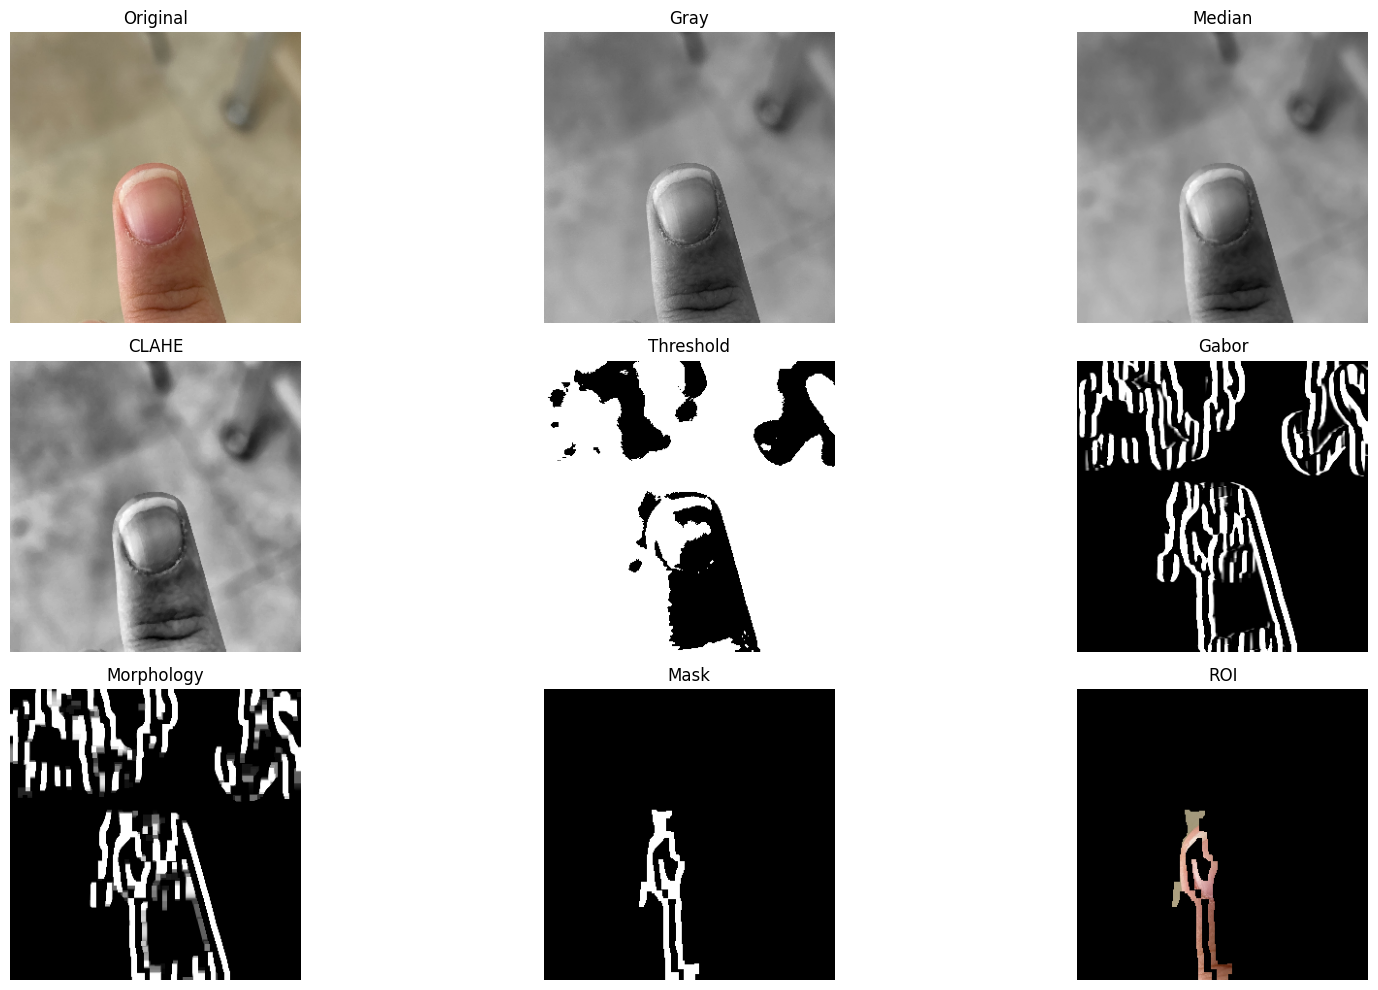

ROI extraction completed.


In [ ]:
image_path = "/content/drive/MyDrive/anemia_detection/test_dataset/nail_1.JPG"

roi = extract_nail_roi(
    image_path=image_path,
    save_path="/content/nail_roi.jpg",
    show_steps=True
)

print("ROI extraction completed.")

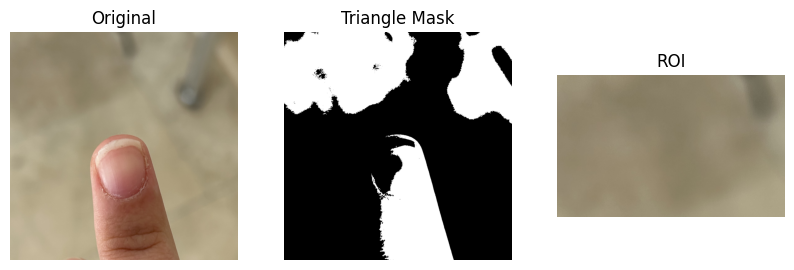

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Görüntü
img = cv2.imread('/content/drive/MyDrive/anemia_detection/test_dataset/nail_1.JPG')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 1️⃣ Griye çevir
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 2️⃣ Triangle threshold
_, thresh = cv2.threshold(gray, 0, 255,
                          cv2.THRESH_BINARY + cv2.THRESH_TRIANGLE)

# 3️⃣ Ters çevir (tırnak açık renk olduğu için)
mask = cv2.bitwise_not(thresh)

# 4️⃣ Küçük temizlik (opsiyonel ama önerilir)
kernel = np.ones((3,3), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

# 5️⃣ Konturlar
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL,
                               cv2.CHAIN_APPROX_SIMPLE)

# En büyük kontur = ROI
cnt = max(contours, key=cv2.contourArea)

# Bounding box
x, y, w, h = cv2.boundingRect(cnt)
roi = img_rgb[y:y+h, x:x+w]

# Göster
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img_rgb)
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Triangle Mask")
plt.imshow(mask, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("ROI")
plt.imshow(roi)
plt.axis('off')

plt.show()